In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../updated_marketing_campaign_dataset.csv')

df.head()

,Campaign_ID,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Duration_Days,Target_Gender,Target_Age
0,1,Innovate Industries,Email,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,01/01/21,30,Men,18-24
1,2,NexGen Systems,Email,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,02/01/21,60,Women,35-44
2,3,Alpha Innovations,Influencer,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,03/01/21,30,Men,25-34
3,4,DataTech Solutions,Display,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,04/01/21,60,All,Ages
4,5,NexGen Systems,Email,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,05/01/21,15,Men,25-34


In [3]:
df['Duration_Category'] = pd.cut(
    df['Duration_Days'],
    bins=[0,30,60,100],
    labels=['Below 30','30-60','60+']
)

In [4]:
duration_roi = df.groupby('Duration_Category')['ROI'].mean()

print(duration_roi)

Duration_Category
Below 30    5.002832
30-60       5.002043
Name: ROI, dtype: float64


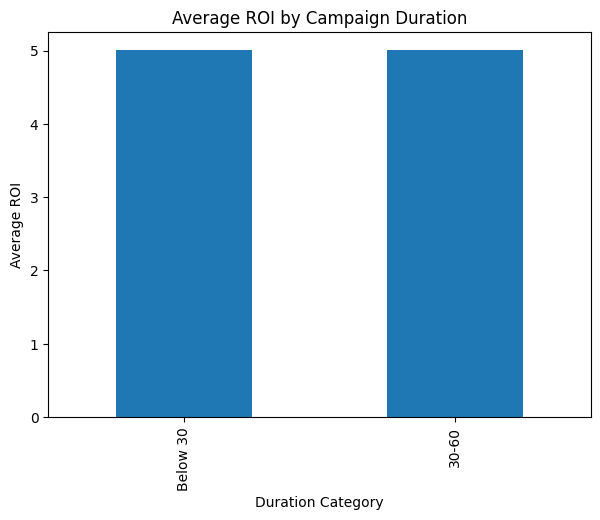

In [5]:
plt.figure(figsize=(7,5))

duration_roi.plot(kind='bar')

plt.title("Average ROI by Campaign Duration")
plt.xlabel("Duration Category")
plt.ylabel("Average ROI")

plt.show()

In [6]:
channel_roi = df.groupby('Channel_Used')['ROI'].mean()

print(channel_roi.sort_values(ascending=False))

Channel_Used
Facebook      5.018699
Website       5.014167
Google Ads    5.003141
Email         4.996487
YouTube       4.993754
Instagram     4.988706
Name: ROI, dtype: float64


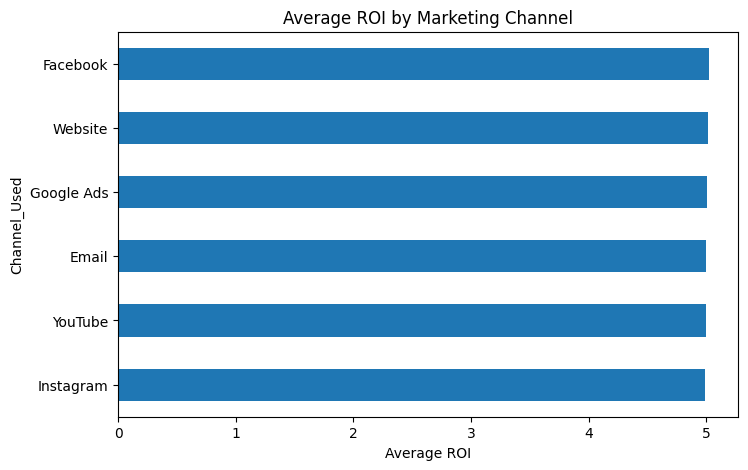

In [7]:
plt.figure(figsize=(8,5))

channel_roi.sort_values().plot(kind='barh')

plt.title("Average ROI by Marketing Channel")
plt.xlabel("Average ROI")

plt.show()

In [8]:
gender_roi = df.groupby('Target_Gender')['ROI'].mean()

print(gender_roi)

Target_Gender
All      5.005174
Men      5.001685
Women    5.001822
Name: ROI, dtype: float64


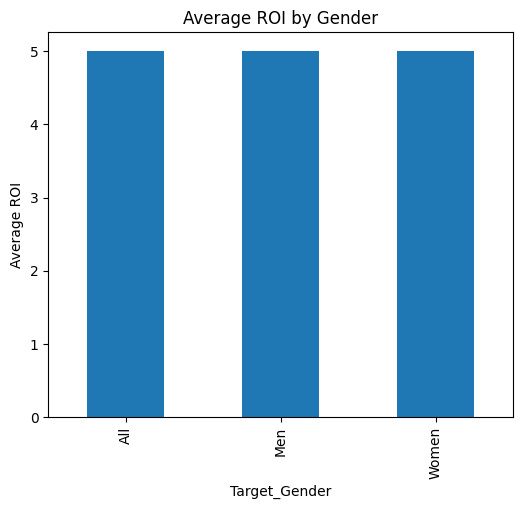

In [9]:
plt.figure(figsize=(6,5))

gender_roi.plot(kind='bar')

plt.title("Average ROI by Gender")
plt.ylabel("Average ROI")

plt.show()

In [10]:
df['Acquisition_Cost'] = (
    df['Acquisition_Cost']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/var/folders/wr/mm1996jd4p9grx5zzl61s8h40000gn/T/ipykernel_67159/765816765.py:3: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


In [11]:
cost_analysis = df.groupby('Channel_Used')['Acquisition_Cost'].mean()

print(cost_analysis.sort_values())

Channel_Used
YouTube       12481.390213
Website       12487.814748
Instagram     12491.760002
Facebook      12510.900942
Email         12526.387809
Google Ads    12528.031401
Name: Acquisition_Cost, dtype: float64


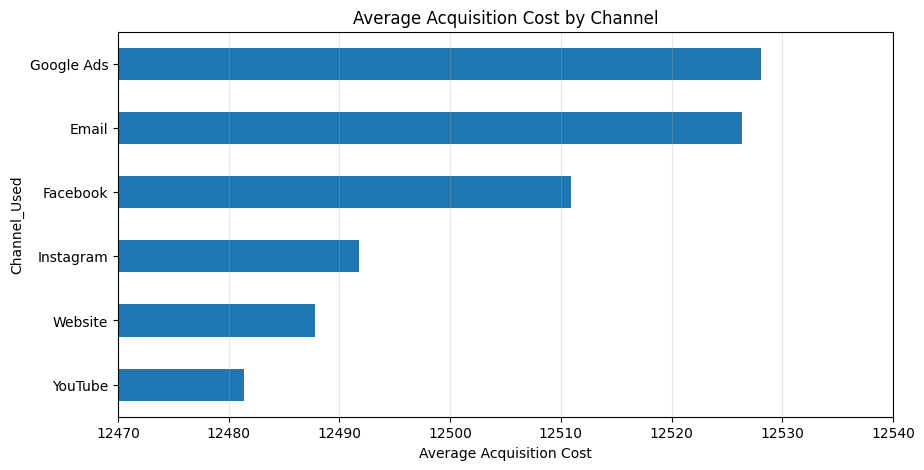

In [13]:
plt.figure(figsize=(10,5))

cost_analysis.sort_values().plot(kind='barh')

plt.xlim(12470, 12540)

plt.title("Average Acquisition Cost by Channel")
plt.xlabel("Average Acquisition Cost")

plt.grid(axis='x', alpha=0.3)

plt.show()

In [14]:
best_combo = df.groupby(
    ['Campaign_Type',
     'Channel_Used',
     'Target_Gender']
)['ROI'].mean().sort_values(ascending=False)

print(best_combo.head(10))

Campaign_Type  Channel_Used  Target_Gender
Display        Website       All              5.105943
Influencer     Website       All              5.096439
Display        Email         Women            5.087983
Email          Facebook      All              5.086991
Search         Website       Men              5.081561
Email          Instagram     All              5.079477
Influencer     Facebook      Women            5.070856
               YouTube       Women            5.070056
Display        Google Ads    All              5.061578
Email          Google Ads    All              5.059437
Name: ROI, dtype: float64


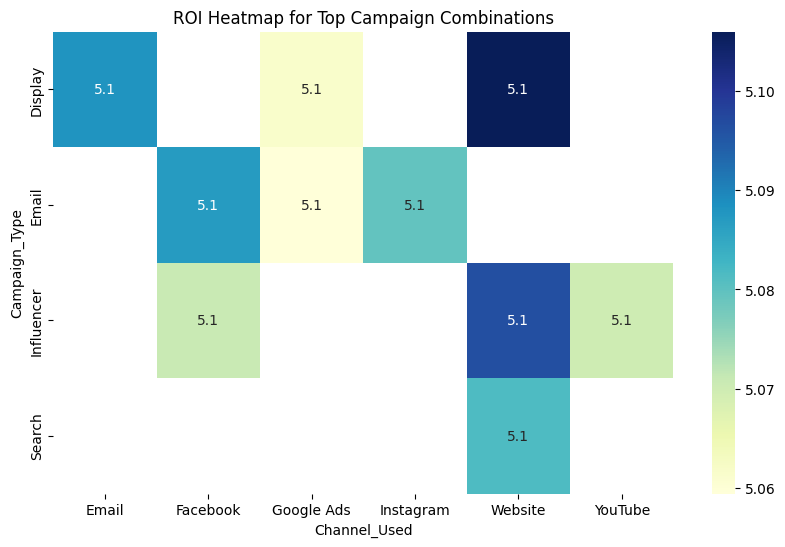

In [16]:
top_df = top_combo.reset_index()

pivot_table = top_df.pivot_table(
    values='ROI',
    index='Campaign_Type',
    columns='Channel_Used'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='YlGnBu'
)

plt.title("ROI Heatmap for Top Campaign Combinations")

plt.show()